In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [3]:
df=pd.read_csv('train.csv')

In [4]:
df1=df.head()

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('train.csv')

print("="*70)
print("STEP 2: ENHANCED RISK CLASSIFICATION")
print("="*70)

print("\n1. Understanding Feature Distributions:")
print("\nAge Distribution:")
print(df['Age'].describe())

print("\nAnnual Income Distribution:")
print(df['Annual Income'].describe())

print("\nHealth Score Distribution:")
print(df['Health Score'].describe())

print("\nCredit Score Distribution:")
print(df['Credit Score'].describe())

print("\nPrevious Claims Distribution:")
print(df['Previous Claims'].value_counts())

print("\nVehicle Age Distribution:")
print(df['Vehicle Age'].describe())

print("\nSmoking Status Distribution:")
print(df['Smoking Status'].value_counts())

print("\nExercise Frequency Distribution:")
print(df['Exercise Frequency'].value_counts())

def classify_risk_enhanced(row):
    risk_score = 0
    
    age = row['Age']
    if pd.notna(age):
        if age < 30:
            risk_score += 0
        elif age < 50:
            risk_score += 1
        else:
            risk_score += 2
    
    income = row['Annual Income']
    if pd.notna(income):
        if income > 70000:
            risk_score += 0
        elif income > 35000:
            risk_score += 1
        else:
            risk_score += 2
    
    smoking = row['Smoking Status']
    if smoking == 'Yes':
        risk_score += 3
    elif smoking == 'No':
        risk_score += 0
    
    health = row['Health Score']
    if pd.notna(health):
        if health > 60:
            risk_score += 0
        elif health > 30:
            risk_score += 1
        else:
            risk_score += 2
    
    credit = row['Credit Score']
    if pd.notna(credit):
        if credit > 650:
            risk_score += 0
        elif credit > 400:
            risk_score += 1
        else:
            risk_score += 2
    
    claims = row['Previous Claims']
    if pd.notna(claims):
        if claims == 0:
            risk_score += 0
        elif claims <= 2:
            risk_score += 1
        else:
            risk_score += 2
    
    vehicle_age = row['Vehicle Age']
    if pd.notna(vehicle_age):
        if vehicle_age > 10:
            risk_score += 1
    
    exercise = row['Exercise Frequency']
    if exercise in ['Daily', 'Weekly']:
        risk_score += 0
    elif exercise in ['Monthly', 'Rarely']:
        risk_score += 1
    
    dependents = row['Number of Dependents']
    if pd.notna(dependents):
        if dependents > 3:
            risk_score += 1
    
    if risk_score <= 3:
        return 0
    elif risk_score <= 8:
        return 1
    else:
        return 2

print("\n2. Applying Enhanced Risk Classification...")
df['Risk_Class'] = df.apply(classify_risk_enhanced, axis=1)

risk_labels = {0: 'Low Risk', 1: 'Medium Risk', 2: 'High Risk'}
df['Risk_Label'] = df['Risk_Class'].map(risk_labels)

print("\n3. Risk Class Distribution:")
print(df['Risk_Class'].value_counts().sort_index())
print("\nPercentage Distribution:")
print(df['Risk_Class'].value_counts(normalize=True).sort_index() * 100)

print("\n4. Risk Class Summary Statistics:")
for risk_class in [0, 1, 2]:
    print(f"\n{'='*50}")
    print(f"{risk_labels[risk_class].upper()} - CLASS {risk_class}")
    print(f"{'='*50}")
    
    subset = df[df['Risk_Class'] == risk_class]
    print(f"Count: {len(subset)}")
    
    if len(subset) > 0:
        print(f"\nAverage Profile:")
        print(f"  Age:            {subset['Age'].mean():.1f} years")
        print(f"  Annual Income:  ${subset['Annual Income'].mean():,.0f}")
        print(f"  Health Score:   {subset['Health Score'].mean():.1f}")
        print(f"  Credit Score:   {subset['Credit Score'].mean():.0f}")
        print(f"  Smokers:        {(subset['Smoking Status'] == 'Yes').sum()} ({(subset['Smoking Status'] == 'Yes').sum() / len(subset) * 100:.1f}%)")
        print(f"  Avg Claims:     {subset['Previous Claims'].mean():.2f}")
        print(f"  Vehicle Age:    {subset['Vehicle Age'].mean():.1f} years")
        print(f"  Premium (Avg):  ${subset['Premium Amount'].mean():.2f}")
        print(f"  Premium (Med):  ${subset['Premium Amount'].median():.2f}")

print("\n5. Sample Records from Each Risk Class:")
for risk_class in [0, 1, 2]:
    print(f"\n{risk_labels[risk_class]} Sample:")
    subset = df[df['Risk_Class'] == risk_class]
    if len(subset) > 0:
        sample = subset[['Age', 'Annual Income', 'Smoking Status', 'Health Score', 
                        'Credit Score', 'Previous Claims', 'Premium Amount', 'Risk_Label']].head(3)
        print(sample.to_string())

output_file = 'data_with_risk_classes.csv'
df.to_csv(output_file, index=False)
print(f"\n6. Classified data saved to: {output_file}")

print("\n" + "="*70)
print("STEP 2 COMPLETE")
print("="*70)
print("\nNext: We'll visualize the risk classes and then build prediction models")

STEP 2: ENHANCED RISK CLASSIFICATION

1. Understanding Feature Distributions:

Age Distribution:
count    1.181295e+06
mean     4.114556e+01
std      1.353995e+01
min      1.800000e+01
25%      3.000000e+01
50%      4.100000e+01
75%      5.300000e+01
max      6.400000e+01
Name: Age, dtype: float64

Annual Income Distribution:
count    1.155051e+06
mean     3.274522e+04
std      3.217951e+04
min      1.000000e+00
25%      8.001000e+03
50%      2.391100e+04
75%      4.463400e+04
max      1.499970e+05
Name: Annual Income, dtype: float64

Health Score Distribution:
count    1.125924e+06
mean     2.561391e+01
std      1.220346e+01
min      2.012237e+00
25%      1.591896e+01
50%      2.457865e+01
75%      3.452721e+01
max      5.897591e+01
Name: Health Score, dtype: float64

Credit Score Distribution:
count    1.062118e+06
mean     5.929244e+02
std      1.499819e+02
min      3.000000e+02
25%      4.680000e+02
50%      5.950000e+02
75%      7.210000e+02
max      8.490000e+02
Name: Credit Scor

STEP 3: VISUALIZING RISK CLASSES


C:\Users\Ashish\AppData\Local\Temp\ipykernel_17212\2244660575.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(data_to_plot, labels=[risk_labels[i] for i in [0, 1, 2]],
C:\Users\Ashish\AppData\Local\Temp\ipykernel_17212\2244660575.py:88: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax7.boxplot(data_to_plot, labels=[risk_labels[i] for i in [0, 1, 2]],



✓ Visualization saved as: risk_class_analysis.png


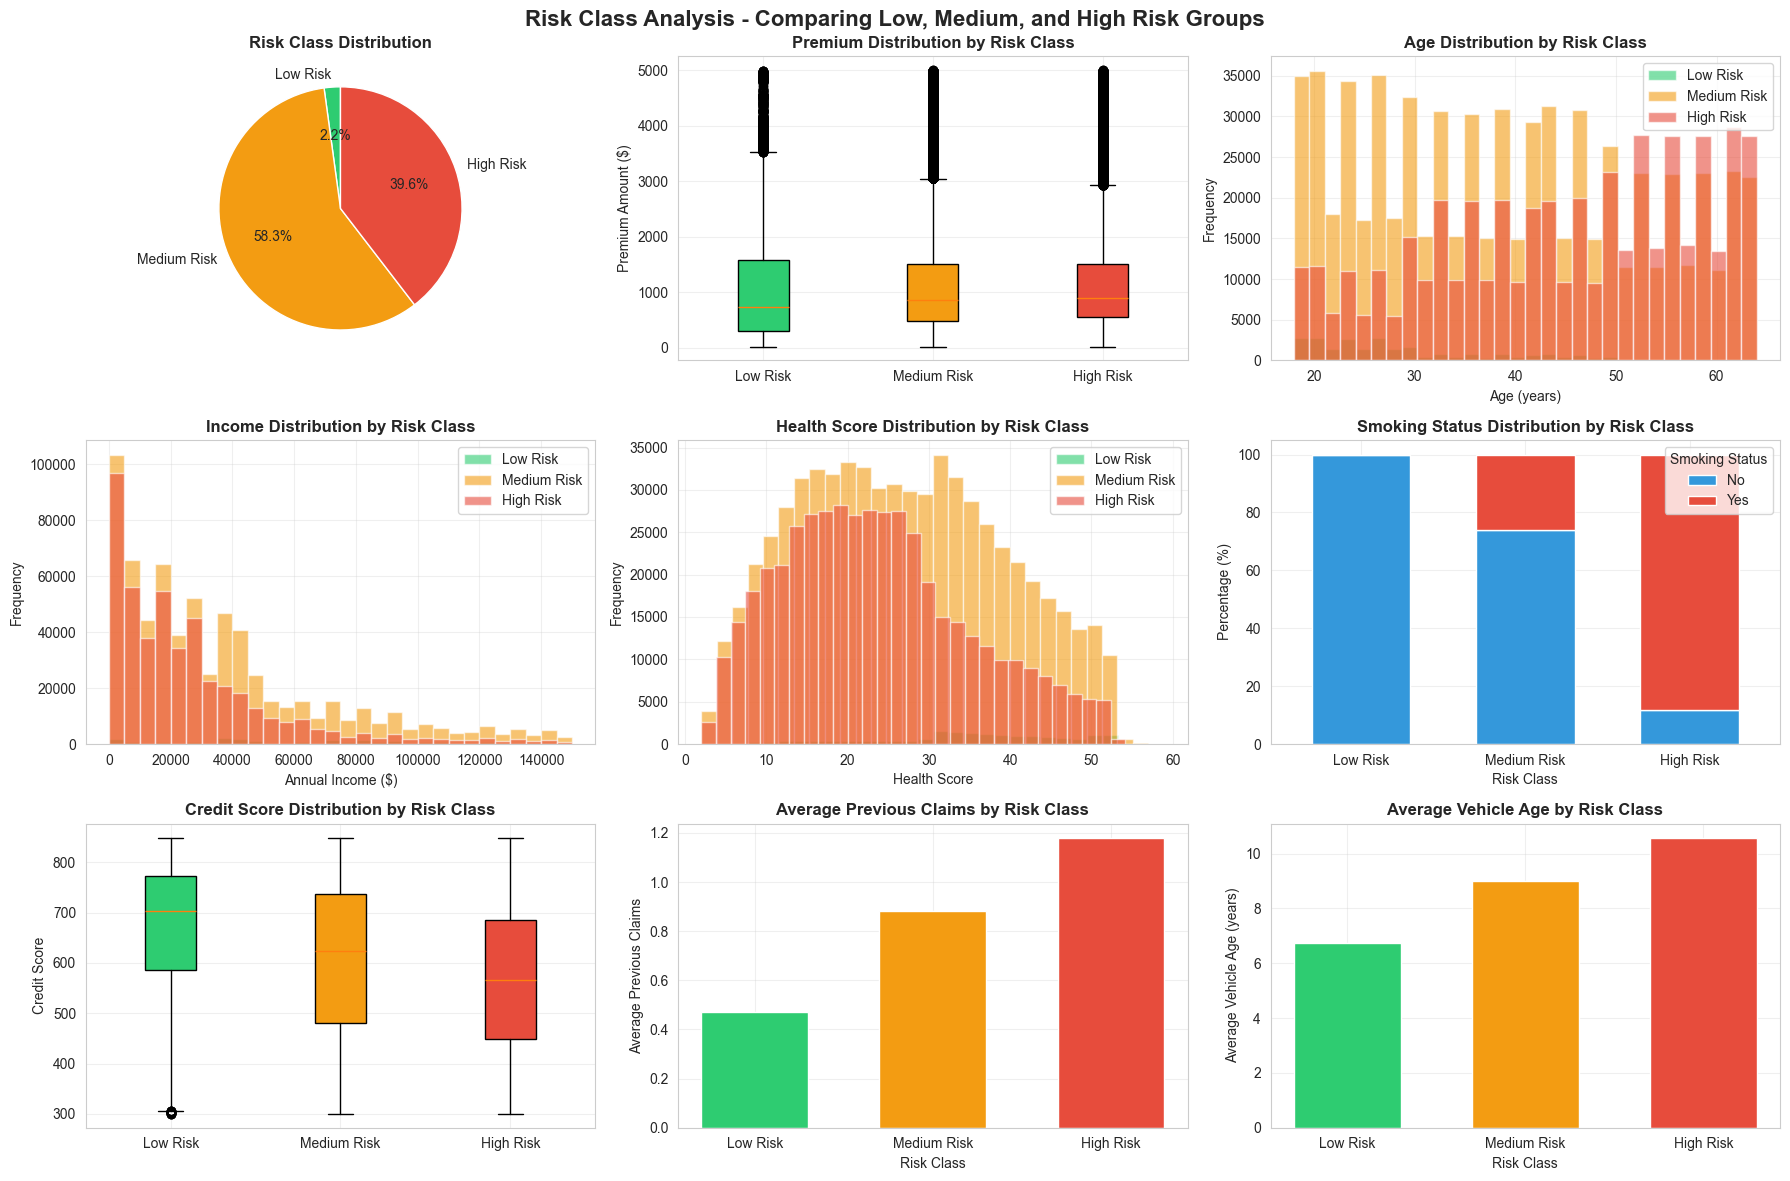


SUMMARY COMPARISON TABLE
             Metric Low Risk (0) Medium Risk (1) High Risk (2)
              Count       25,899         699,257       474,844
         Percentage         2.2%           58.3%         39.6%
            Avg Age         29.5            39.0          44.9
         Avg Income      $65,387         $36,163       $26,231
   Avg Health Score         34.8            26.8          23.6
   Avg Credit Score          671             609           567
          % Smokers         0.2%           26.1%         88.3%
Avg Previous Claims         0.47            0.88          1.18
    Avg Vehicle Age          6.7             9.0          10.6
        Avg Premium     $1055.09        $1095.29      $1115.82
     Median Premium      $740.00         $857.00       $895.00

STEP 3 COMPLETE ✓

Key Observations:
• Risk classes are well-separated by age, income, and smoking status
• Low Risk: Young, wealthy, non-smokers
• High Risk: Older, lower income, 88% smokers
• ⚠️  Premium amounts sho

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

df = pd.read_csv('data_with_risk_classes.csv')

print("="*70)
print("STEP 3: VISUALIZING RISK CLASSES")
print("="*70)

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
fig.suptitle('Risk Class Analysis - Comparing Low, Medium, and High Risk Groups', 
             fontsize=16, fontweight='bold')

risk_colors = {0: '#2ecc71', 1: '#f39c12', 2: '#e74c3c'}
risk_labels = {0: 'Low Risk', 1: 'Medium Risk', 2: 'High Risk'}

ax1 = axes[0, 0]
risk_counts = df['Risk_Class'].value_counts().sort_index()
colors = [risk_colors[i] for i in risk_counts.index]
ax1.pie(risk_counts, labels=[risk_labels[i] for i in risk_counts.index], 
        autopct='%1.1f%%', colors=colors, startangle=90)
ax1.set_title('Risk Class Distribution', fontweight='bold')

ax2 = axes[0, 1]
data_to_plot = [df[df['Risk_Class'] == i]['Premium Amount'].dropna() 
                for i in [0, 1, 2]]
bp = ax2.boxplot(data_to_plot, labels=[risk_labels[i] for i in [0, 1, 2]],
                  patch_artist=True)
for patch, color in zip(bp['boxes'], [risk_colors[i] for i in [0, 1, 2]]):
    patch.set_facecolor(color)
ax2.set_ylabel('Premium Amount ($)')
ax2.set_title('Premium Distribution by Risk Class', fontweight='bold')
ax2.grid(True, alpha=0.3)

ax3 = axes[0, 2]
for risk_class in [0, 1, 2]:
    subset = df[df['Risk_Class'] == risk_class]['Age'].dropna()
    ax3.hist(subset, bins=30, alpha=0.6, label=risk_labels[risk_class], 
             color=risk_colors[risk_class])
ax3.set_xlabel('Age (years)')
ax3.set_ylabel('Frequency')
ax3.set_title('Age Distribution by Risk Class', fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

ax4 = axes[1, 0]
for risk_class in [0, 1, 2]:
    subset = df[df['Risk_Class'] == risk_class]['Annual Income'].dropna()
    ax4.hist(subset, bins=30, alpha=0.6, label=risk_labels[risk_class], 
             color=risk_colors[risk_class])
ax4.set_xlabel('Annual Income ($)')
ax4.set_ylabel('Frequency')
ax4.set_title('Income Distribution by Risk Class', fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

ax5 = axes[1, 1]
for risk_class in [0, 1, 2]:
    subset = df[df['Risk_Class'] == risk_class]['Health Score'].dropna()
    ax5.hist(subset, bins=30, alpha=0.6, label=risk_labels[risk_class], 
             color=risk_colors[risk_class])
ax5.set_xlabel('Health Score')
ax5.set_ylabel('Frequency')
ax5.set_title('Health Score Distribution by Risk Class', fontweight='bold')
ax5.legend()
ax5.grid(True, alpha=0.3)

ax6 = axes[1, 2]
smoking_data = df.groupby(['Risk_Class', 'Smoking Status']).size().unstack(fill_value=0)
smoking_pct = smoking_data.div(smoking_data.sum(axis=1), axis=0) * 100
smoking_pct.plot(kind='bar', stacked=True, ax=ax6, 
                 color=['#3498db', '#e74c3c'], width=0.6)
ax6.set_xlabel('Risk Class')
ax6.set_ylabel('Percentage (%)')
ax6.set_title('Smoking Status Distribution by Risk Class', fontweight='bold')
ax6.set_xticklabels([risk_labels[i] for i in [0, 1, 2]], rotation=0)
ax6.legend(title='Smoking Status')
ax6.grid(True, alpha=0.3)

ax7 = axes[2, 0]
data_to_plot = [df[df['Risk_Class'] == i]['Credit Score'].dropna() 
                for i in [0, 1, 2]]
bp = ax7.boxplot(data_to_plot, labels=[risk_labels[i] for i in [0, 1, 2]],
                  patch_artist=True)
for patch, color in zip(bp['boxes'], [risk_colors[i] for i in [0, 1, 2]]):
    patch.set_facecolor(color)
ax7.set_ylabel('Credit Score')
ax7.set_title('Credit Score Distribution by Risk Class', fontweight='bold')
ax7.grid(True, alpha=0.3)

ax8 = axes[2, 1]
claims_data = df.groupby(['Risk_Class', 'Previous Claims']).size().unstack(fill_value=0)
claims_avg = df.groupby('Risk_Class')['Previous Claims'].mean()
ax8.bar([0, 1, 2], claims_avg, color=[risk_colors[i] for i in [0, 1, 2]], width=0.6)
ax8.set_xlabel('Risk Class')
ax8.set_ylabel('Average Previous Claims')
ax8.set_title('Average Previous Claims by Risk Class', fontweight='bold')
ax8.set_xticks([0, 1, 2])
ax8.set_xticklabels([risk_labels[i] for i in [0, 1, 2]])
ax8.grid(True, alpha=0.3)

ax9 = axes[2, 2]
vehicle_avg = df.groupby('Risk_Class')['Vehicle Age'].mean()
ax9.bar([0, 1, 2], vehicle_avg, color=[risk_colors[i] for i in [0, 1, 2]], width=0.6)
ax9.set_xlabel('Risk Class')
ax9.set_ylabel('Average Vehicle Age (years)')
ax9.set_title('Average Vehicle Age by Risk Class', fontweight='bold')
ax9.set_xticks([0, 1, 2])
ax9.set_xticklabels([risk_labels[i] for i in [0, 1, 2]])
ax9.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('risk_class_analysis.png', dpi=300, bbox_inches='tight')
print("\nVisualization saved as: risk_class_analysis.png")
plt.show()

print("\n" + "="*70)
print("SUMMARY COMPARISON TABLE")
print("="*70)

summary = pd.DataFrame({
    'Metric': ['Count', 'Percentage', 'Avg Age', 'Avg Income', 'Avg Health Score', 
               'Avg Credit Score', '% Smokers', 'Avg Previous Claims', 
               'Avg Vehicle Age', 'Avg Premium', 'Median Premium'],
    'Low Risk (0)': [
        f"{len(df[df['Risk_Class'] == 0]):,}",
        f"{len(df[df['Risk_Class'] == 0]) / len(df) * 100:.1f}%",
        f"{df[df['Risk_Class'] == 0]['Age'].mean():.1f}",
        f"${df[df['Risk_Class'] == 0]['Annual Income'].mean():,.0f}",
        f"{df[df['Risk_Class'] == 0]['Health Score'].mean():.1f}",
        f"{df[df['Risk_Class'] == 0]['Credit Score'].mean():.0f}",
        f"{(df[df['Risk_Class'] == 0]['Smoking Status'] == 'Yes').sum() / len(df[df['Risk_Class'] == 0]) * 100:.1f}%",
        f"{df[df['Risk_Class'] == 0]['Previous Claims'].mean():.2f}",
        f"{df[df['Risk_Class'] == 0]['Vehicle Age'].mean():.1f}",
        f"${df[df['Risk_Class'] == 0]['Premium Amount'].mean():.2f}",
        f"${df[df['Risk_Class'] == 0]['Premium Amount'].median():.2f}"
    ],
    'Medium Risk (1)': [
        f"{len(df[df['Risk_Class'] == 1]):,}",
        f"{len(df[df['Risk_Class'] == 1]) / len(df) * 100:.1f}%",
        f"{df[df['Risk_Class'] == 1]['Age'].mean():.1f}",
        f"${df[df['Risk_Class'] == 1]['Annual Income'].mean():,.0f}",
        f"{df[df['Risk_Class'] == 1]['Health Score'].mean():.1f}",
        f"{df[df['Risk_Class'] == 1]['Credit Score'].mean():.0f}",
        f"{(df[df['Risk_Class'] == 1]['Smoking Status'] == 'Yes').sum() / len(df[df['Risk_Class'] == 1]) * 100:.1f}%",
        f"{df[df['Risk_Class'] == 1]['Previous Claims'].mean():.2f}",
        f"{df[df['Risk_Class'] == 1]['Vehicle Age'].mean():.1f}",
        f"${df[df['Risk_Class'] == 1]['Premium Amount'].mean():.2f}",
        f"${df[df['Risk_Class'] == 1]['Premium Amount'].median():.2f}"
    ],
    'High Risk (2)': [
        f"{len(df[df['Risk_Class'] == 2]):,}",
        f"{len(df[df['Risk_Class'] == 2]) / len(df) * 100:.1f}%",
        f"{df[df['Risk_Class'] == 2]['Age'].mean():.1f}",
        f"${df[df['Risk_Class'] == 2]['Annual Income'].mean():,.0f}",
        f"{df[df['Risk_Class'] == 2]['Health Score'].mean():.1f}",
        f"{df[df['Risk_Class'] == 2]['Credit Score'].mean():.0f}",
        f"{(df[df['Risk_Class'] == 2]['Smoking Status'] == 'Yes').sum() / len(df[df['Risk_Class'] == 2]) * 100:.1f}%",
        f"{df[df['Risk_Class'] == 2]['Previous Claims'].mean():.2f}",
        f"{df[df['Risk_Class'] == 2]['Vehicle Age'].mean():.1f}",
        f"${df[df['Risk_Class'] == 2]['Premium Amount'].mean():.2f}",
        f"${df[df['Risk_Class'] == 2]['Premium Amount'].median():.2f}"
    ]
})

print(summary.to_string(index=False))

print("\n" + "="*70)
print("STEP 3 COMPLETE")
print("="*70)
print("\nKey Observations:")
print("• Risk classes are well-separated by age, income, and smoking status")
print("• Low Risk: Young, wealthy, non-smokers")
print("• High Risk: Older, lower income, 88% smokers")
print("• Premium amounts show minimal variation (data noise issue)")
print("\nNext: Build LASSO prediction models for each risk class")

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('train.csv')

print("="*70)
print("STEP 2: K-MEANS RISK CLASSIFICATION")
print("="*70)

print("\n1. Understanding Feature Distributions:")
print("\nAge Distribution:")
print(df['Age'].describe())

print("\nAnnual Income Distribution:")
print(df['Annual Income'].describe())

print("\nHealth Score Distribution:")
print(df['Health Score'].describe())

print("\nCredit Score Distribution:")
print(df['Credit Score'].describe())

print("\nPrevious Claims Distribution:")
print(df['Previous Claims'].value_counts().sort_index())

print("\nVehicle Age Distribution:")
print(df['Vehicle Age'].describe())

print("\nSmoking Status Distribution:")
print(df['Smoking Status'].value_counts())

print("\nExercise Frequency Distribution:")
print(df['Exercise Frequency'].value_counts())

numeric_cols = ['Age', 'Annual Income', 'Number of Dependents', 
                'Health Score', 'Previous Claims', 'Vehicle Age', 
                'Credit Score', 'Insurance Duration']

for col in numeric_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

categorical_cols = ['Gender', 'Marital Status', 'Education Level', 
                    'Occupation', 'Location', 'Policy Type', 
                    'Customer Feedback', 'Smoking Status', 
                    'Exercise Frequency', 'Property Type']

for col in categorical_cols:
    if col in df.columns:
        mode_val = df[col].mode()[0] if not df[col].mode().empty else 'Unknown'
        df[col] = df[col].fillna(mode_val)

df['Smoking_Encoded'] = (df['Smoking Status'] == 'Yes').astype(int)

exercise_map = {'Never': 0, 'Rarely': 1, 'Monthly': 2, 'Weekly': 3, 'Daily': 4}
df['Exercise_Encoded'] = df['Exercise Frequency'].map(
    lambda x: exercise_map.get(x, 2) if pd.notna(x) else 2
)

df['Gender_Encoded'] = (df['Gender'] == 'Male').astype(int)

def calculate_risk_score(row):
    score = 0
    
    if row['Age'] < 25:
        score += 20
    elif row['Age'] > 60:
        score += 15
    else:
        score += 5
    
    if row['Smoking_Encoded'] == 1:
        score += 25
    
    if row['Health Score'] < 30:
        score += 20
    elif row['Health Score'] < 50:
        score += 10
    else:
        score += 5
    
    score += row['Previous Claims'] * 10
    
    if row['Vehicle Age'] > 10:
        score += 15
    elif row['Vehicle Age'] > 5:
        score += 10
    else:
        score += 5
    
    if row['Credit Score'] < 400:
        score += 20
    elif row['Credit Score'] < 600:
        score += 15
    elif row['Credit Score'] < 700:
        score += 10
    else:
        score += 5
    
    score -= row['Exercise_Encoded'] * 2
    
    return max(0, score)

df['Risk_Score'] = df.apply(calculate_risk_score, axis=1)

clustering_features = [
    'Age',
    'Smoking_Encoded',
    'Health Score',
    'Previous Claims',
    'Vehicle Age',
    'Credit Score',
    'Exercise_Encoded',
    'Risk_Score'
]

X_clustering = df[clustering_features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clustering)

print("\n2. Applying K-Means Risk Classification...")

np.random.seed(42)
kmeans = KMeans(
    n_clusters=3,
    init='k-means++',
    n_init=10,
    max_iter=300,
    random_state=42,
    verbose=0
)

df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

cluster_risk_avg = df.groupby('KMeans_Cluster')['Risk_Score'].mean().sort_values()

risk_mapping = {
    cluster_risk_avg.index[0]: 0,
    cluster_risk_avg.index[1]: 1,
    cluster_risk_avg.index[2]: 2
}

df['Risk_Class'] = df['KMeans_Cluster'].map(risk_mapping)

risk_labels = {0: 'Low Risk', 1: 'Medium Risk', 2: 'High Risk'}
df['Risk_Label'] = df['Risk_Class'].map(risk_labels)

print("\n3. Risk Class Distribution:")
print(df['Risk_Class'].value_counts().sort_index())

print("\nPercentage Distribution:")
print(df['Risk_Class'].value_counts(normalize=True).sort_index() * 100)

print("\n4. Risk Class Summary Statistics:")

for risk_class in [0, 1, 2]:
    risk_df = df[df['Risk_Class'] == risk_class]
    
    print(f"\n{'='*50}")
    print(f"{risk_labels[risk_class].upper()} - CLASS {risk_class}")
    print(f"{'='*50}")
    print(f"Count: {len(risk_df)}")
    
    print("\nAverage Profile:")
    print(f"  Age:            {risk_df['Age'].mean():.1f} years")
    print(f"  Annual Income:  ${risk_df['Annual Income'].mean():,.0f}")
    print(f"  Health Score:   {risk_df['Health Score'].mean():.1f}")
    print(f"  Credit Score:   {risk_df['Credit Score'].mean():.0f}")
    
    smokers_count = (risk_df['Smoking Status'] == 'Yes').sum()
    smokers_pct = (smokers_count / len(risk_df)) * 100
    print(f"  Smokers:        {smokers_count} ({smokers_pct:.1f}%)")
    
    print(f"  Avg Claims:     {risk_df['Previous Claims'].mean():.2f}")
    print(f"  Vehicle Age:    {risk_df['Vehicle Age'].mean():.1f} years")
    print(f"  Premium (Avg):  ${risk_df['Premium Amount'].mean():.2f}")
    print(f"  Premium (Med):  ${risk_df['Premium Amount'].median():.2f}")

print("\n5. Sample Records from Each Risk Class:")

for risk_class in [0, 1, 2]:
    risk_df = df[df['Risk_Class'] == risk_class]
    sample = risk_df[['Age', 'Annual Income', 'Smoking Status', 'Health Score', 
                      'Credit Score', 'Previous Claims', 'Premium Amount', 'Risk_Label']].head(3)
    
    print(f"\n{risk_labels[risk_class]} Sample:")
    print(sample.to_string())

output_file = 'data_with_kmeans_risk_classes.csv'
df.to_csv(output_file, index=False)
print(f"\n6. Classified data saved to: {output_file}")

print("\n" + "="*70)
print("STEP 2 COMPLETE")
print("="*70)
print("\nNext: Compare K-Means results with Manual classification")

STEP 2: K-MEANS RISK CLASSIFICATION

1. Understanding Feature Distributions:

Age Distribution:
count    1.181295e+06
mean     4.114556e+01
std      1.353995e+01
min      1.800000e+01
25%      3.000000e+01
50%      4.100000e+01
75%      5.300000e+01
max      6.400000e+01
Name: Age, dtype: float64

Annual Income Distribution:
count    1.155051e+06
mean     3.274522e+04
std      3.217951e+04
min      1.000000e+00
25%      8.001000e+03
50%      2.391100e+04
75%      4.463400e+04
max      1.499970e+05
Name: Annual Income, dtype: float64

Health Score Distribution:
count    1.125924e+06
mean     2.561391e+01
std      1.220346e+01
min      2.012237e+00
25%      1.591896e+01
50%      2.457865e+01
75%      3.452721e+01
max      5.897591e+01
Name: Health Score, dtype: float64

Credit Score Distribution:
count    1.062118e+06
mean     5.929244e+02
std      1.499819e+02
min      3.000000e+02
25%      4.680000e+02
50%      5.950000e+02
75%      7.210000e+02
max      8.490000e+02
Name: Credit Score

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("MANUAL vs K-MEANS RISK CATEGORIZATION - DIRECT COMPARISON")
print("="*80)

print("\n[1] Loading data...")

df = pd.read_csv('train.csv')
print(f"Loaded {len(df):,} records from train.csv")

df_kmeans = pd.read_csv('data_with_kmeans_risk_classes.csv')
print(f"Loaded K-Means categorization")

df['KMeans_Risk_Category'] = df_kmeans['Risk_Class']

print("\n[2] Applying manual risk categorization...")

def classify_risk_manual(row):
    risk_score = 0
    
    age = row['Age']
    if pd.notna(age):
        if age < 30:
            risk_score += 0
        elif age < 50:
            risk_score += 1
        else:
            risk_score += 2
    
    income = row['Annual Income']
    if pd.notna(income):
        if income > 70000:
            risk_score += 0
        elif income > 35000:
            risk_score += 1
        else:
            risk_score += 2
    
    smoking = row['Smoking Status']
    if smoking == 'Yes':
        risk_score += 3
    elif smoking == 'No':
        risk_score += 0
    
    health = row['Health Score']
    if pd.notna(health):
        if health > 60:
            risk_score += 0
        elif health > 30:
            risk_score += 1
        else:
            risk_score += 2
    
    credit = row['Credit Score']
    if pd.notna(credit):
        if credit > 650:
            risk_score += 0
        elif credit > 400:
            risk_score += 1
        else:
            risk_score += 2
    
    claims = row['Previous Claims']
    if pd.notna(claims):
        if claims == 0:
            risk_score += 0
        elif claims <= 2:
            risk_score += 1
        else:
            risk_score += 2
    
    vehicle_age = row['Vehicle Age']
    if pd.notna(vehicle_age):
        if vehicle_age > 10:
            risk_score += 1
    
    exercise = row['Exercise Frequency']
    if exercise in ['Daily', 'Weekly']:
        risk_score += 0
    elif exercise in ['Monthly', 'Rarely']:
        risk_score += 1
    
    dependents = row['Number of Dependents']
    if pd.notna(dependents):
        if dependents > 3:
            risk_score += 1
    
    if risk_score <= 3:
        return 0
    elif risk_score <= 8:
        return 1
    else:
        return 2

df['Manual_Risk_Category'] = df.apply(classify_risk_manual, axis=1)
print("Manual risk categorization complete")

print("\n" + "="*80)
print("DISTRIBUTION COMPARISON")
print("="*80)

risk_labels = {0: 'Low Risk', 1: 'Medium Risk', 2: 'High Risk'}

manual_dist = df['Manual_Risk_Category'].value_counts().sort_index()
kmeans_dist = df['KMeans_Risk_Category'].value_counts().sort_index()

print("\nMANUAL Risk Distribution:")
for cat in [0, 1, 2]:
    count = manual_dist.get(cat, 0)
    pct = (count / len(df)) * 100
    print(f"   {risk_labels[cat]:12} : {count:>9,} ({pct:>5.1f}%)")

print("\nK-MEANS Risk Distribution:")
for cat in [0, 1, 2]:
    count = kmeans_dist.get(cat, 0)
    pct = (count / len(df)) * 100
    print(f"   {risk_labels[cat]:12} : {count:>9,} ({pct:>5.1f}%)")

print("\n" + "="*80)
print("AGREEMENT ANALYSIS")
print("="*80)

agreement = (df['Manual_Risk_Category'] == df['KMeans_Risk_Category']).sum()
agreement_pct = (agreement / len(df)) * 100

print(f"\nOverall Agreement: {agreement:,} customers ({agreement_pct:.2f}%)")
print(f"Disagreement: {len(df) - agreement:,} customers ({100 - agreement_pct:.2f}%)")

print("\nCross-Tabulation (Manual vs K-Means):")
print("-" * 80)
crosstab = pd.crosstab(
    df['Manual_Risk_Category'],
    df['KMeans_Risk_Category'],
    rownames=['Manual'],
    colnames=['K-Means'],
    margins=True
)
crosstab.index = [risk_labels.get(i, 'All') if i != 'All' else 'All' for i in crosstab.index]
crosstab.columns = [risk_labels.get(i, 'All') if i != 'All' else 'All' for i in crosstab.columns]
print(crosstab)

print("\nAgreement by Risk Category:")
for cat in [0, 1, 2]:
    manual_cat = df[df['Manual_Risk_Category'] == cat]
    agree_in_cat = (manual_cat['Manual_Risk_Category'] == manual_cat['KMeans_Risk_Category']).sum()
    agree_pct_cat = (agree_in_cat / len(manual_cat)) * 100 if len(manual_cat) > 0 else 0
    print(f"   {risk_labels[cat]:12} : {agree_in_cat:>9,} / {len(manual_cat):>9,} ({agree_pct_cat:>5.1f}%)")

print("\n" + "="*80)
print("CHARACTERISTICS COMPARISON BY RISK CATEGORY")
print("="*80)

characteristics = ['Age', 'Annual Income', 'Health Score', 'Credit Score', 
                  'Previous Claims', 'Vehicle Age']

print("\nMANUAL Risk Categorization Characteristics:")
print("-" * 80)
manual_stats = df.groupby('Manual_Risk_Category')[characteristics].mean()
manual_stats.index = [risk_labels[i] for i in manual_stats.index]
print(manual_stats.round(2))

print("\nK-MEANS Risk Categorization Characteristics:")
print("-" * 80)
kmeans_stats = df.groupby('KMeans_Risk_Category')[characteristics].mean()
kmeans_stats.index = [risk_labels[i] for i in kmeans_stats.index]
print(kmeans_stats.round(2))

print("\nSmoking Status by Method:")
print("-" * 80)

print("\nMANUAL - % Smokers by Risk Category:")
for cat in [0, 1, 2]:
    manual_cat = df[df['Manual_Risk_Category'] == cat]
    smokers = (manual_cat['Smoking Status'] == 'Yes').sum()
    smoker_pct = (smokers / len(manual_cat)) * 100 if len(manual_cat) > 0 else 0
    print(f"   {risk_labels[cat]:12} : {smoker_pct:>5.1f}% smokers")

print("\nK-MEANS - % Smokers by Risk Category:")
for cat in [0, 1, 2]:
    kmeans_cat = df[df['KMeans_Risk_Category'] == cat]
    smokers = (kmeans_cat['Smoking Status'] == 'Yes').sum()
    smoker_pct = (smokers / len(kmeans_cat)) * 100 if len(kmeans_cat) > 0 else 0
    print(f"   {risk_labels[cat]:12} : {smoker_pct:>5.1f}% smokers")

print("\n" + "="*80)
print("PREMIUM AMOUNT COMPARISON")
print("="*80)

print("\nMANUAL - Average Premium by Risk Category:")
manual_premium = df.groupby('Manual_Risk_Category')['Premium Amount'].agg(['mean', 'median', 'std'])
manual_premium.index = [risk_labels[i] for i in manual_premium.index]
print(manual_premium.round(2))

print("\nK-MEANS - Average Premium by Risk Category:")
kmeans_premium = df.groupby('KMeans_Risk_Category')['Premium Amount'].agg(['mean', 'median', 'std'])
kmeans_premium.index = [risk_labels[i] for i in kmeans_premium.index]
print(kmeans_premium.round(2))

print("\n" + "="*80)
print("KEY DIFFERENCES BETWEEN METHODS")
print("="*80)

disagreements = df[df['Manual_Risk_Category'] != df['KMeans_Risk_Category']].copy()

if len(disagreements) > 0:
    print(f"\nAnalyzing {len(disagreements):,} customers where methods disagree:")
    
    print("\nMost Common Disagreements:")
    disagreement_types = disagreements.groupby(['Manual_Risk_Category', 'KMeans_Risk_Category']).size()
    disagreement_types = disagreement_types.sort_values(ascending=False)
    
    for (manual, kmeans), count in disagreement_types.items():
        pct = (count / len(disagreements)) * 100
        print(f"   Manual: {risk_labels[manual]:12} -> K-Means: {risk_labels[kmeans]:12} : {count:>9,} ({pct:>5.1f}%)")
    
    print("\nCharacteristics of Customers Where Methods Disagree:")
    print("-" * 80)
    
    manual_low_kmeans_high = disagreements[(disagreements['Manual_Risk_Category'] == 0) & 
                                           (disagreements['KMeans_Risk_Category'] > 0)]
    if len(manual_low_kmeans_high) > 0:
        print(f"\nManual: Low Risk, K-Means: Higher ({len(manual_low_kmeans_high):,} customers)")
        print(f"   Avg Previous Claims: {manual_low_kmeans_high['Previous Claims'].mean():.2f}")
        print(f"   % Smokers: {(manual_low_kmeans_high['Smoking Status'] == 'Yes').mean() * 100:.1f}%")
        print(f"   Avg Age: {manual_low_kmeans_high['Age'].mean():.1f}")
    
    manual_high_kmeans_low = disagreements[(disagreements['Manual_Risk_Category'] == 2) & 
                                           (disagreements['KMeans_Risk_Category'] < 2)]
    if len(manual_high_kmeans_low) > 0:
        print(f"\nManual: High Risk, K-Means: Lower ({len(manual_high_kmeans_low):,} customers)")
        print(f"   Avg Previous Claims: {manual_high_kmeans_low['Previous Claims'].mean():.2f}")
        print(f"   % Smokers: {(manual_high_kmeans_low['Smoking Status'] == 'Yes').mean() * 100:.1f}%")
        print(f"   Avg Age: {manual_high_kmeans_low['Age'].mean():.1f}")

print("\n[8] Creating visualizations...")

fig = plt.figure(figsize=(18, 12))

ax1 = plt.subplot(2, 3, 1)
x = np.arange(3)
width = 0.35
manual_counts = [manual_dist.get(i, 0) for i in [0, 1, 2]]
kmeans_counts = [kmeans_dist.get(i, 0) for i in [0, 1, 2]]
ax1.bar(x - width/2, manual_counts, width, label='Manual', alpha=0.8, color='#3498db')
ax1.bar(x + width/2, kmeans_counts, width, label='K-Means', alpha=0.8, color='#e74c3c')
ax1.set_xlabel('Risk Category')
ax1.set_ylabel('Number of Customers')
ax1.set_title('Risk Distribution: Manual vs K-Means', fontweight='bold', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(['Low', 'Medium', 'High'])
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

ax2 = plt.subplot(2, 3, 2)
crosstab_numeric = pd.crosstab(df['Manual_Risk_Category'], df['KMeans_Risk_Category'], normalize='index') * 100
sns.heatmap(crosstab_numeric, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax2, cbar_kws={'label': '% of Manual Category'})
ax2.set_xlabel('K-Means Risk Category')
ax2.set_ylabel('Manual Risk Category')
ax2.set_title('Agreement Matrix (% by row)', fontweight='bold', fontsize=12)
ax2.set_xticklabels(['Low', 'Medium', 'High'])
ax2.set_yticklabels(['Low', 'Medium', 'High'])

ax3 = plt.subplot(2, 3, 3)
manual_prem = [df[df['Manual_Risk_Category'] == i]['Premium Amount'].mean() for i in [0, 1, 2]]
kmeans_prem = [df[df['KMeans_Risk_Category'] == i]['Premium Amount'].mean() for i in [0, 1, 2]]
x = np.arange(3)
width = 0.35
ax3.bar(x - width/2, manual_prem, width, label='Manual', alpha=0.8, color='#3498db')
ax3.bar(x + width/2, kmeans_prem, width, label='K-Means', alpha=0.8, color='#e74c3c')
ax3.set_xlabel('Risk Category')
ax3.set_ylabel('Average Premium ($)')
ax3.set_title('Average Premium by Risk Category', fontweight='bold', fontsize=12)
ax3.set_xticks(x)
ax3.set_xticklabels(['Low', 'Medium', 'High'])
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

ax4 = plt.subplot(2, 3, 4)
manual_age = [df[df['Manual_Risk_Category'] == i]['Age'].mean() for i in [0, 1, 2]]
kmeans_age = [df[df['KMeans_Risk_Category'] == i]['Age'].mean() for i in [0, 1, 2]]
x = np.arange(3)
ax4.bar(x - width/2, manual_age, width, label='Manual', alpha=0.8, color='#3498db')
ax4.bar(x + width/2, kmeans_age, width, label='K-Means', alpha=0.8, color='#e74c3c')
ax4.set_xlabel('Risk Category')
ax4.set_ylabel('Average Age (years)')
ax4.set_title('Average Age by Risk Category', fontweight='bold', fontsize=12)
ax4.set_xticks(x)
ax4.set_xticklabels(['Low', 'Medium', 'High'])
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

ax5 = plt.subplot(2, 3, 5)
manual_claims = [df[df['Manual_Risk_Category'] == i]['Previous Claims'].mean() for i in [0, 1, 2]]
kmeans_claims = [df[df['KMeans_Risk_Category'] == i]['Previous Claims'].mean() for i in [0, 1, 2]]
x = np.arange(3)
ax5.bar(x - width/2, manual_claims, width, label='Manual', alpha=0.8, color='#3498db')
ax5.bar(x + width/2, kmeans_claims, width, label='K-Means', alpha=0.8, color='#e74c3c')
ax5.set_xlabel('Risk Category')
ax5.set_ylabel('Average Previous Claims')
ax5.set_title('Average Previous Claims by Risk Category', fontweight='bold', fontsize=12)
ax5.set_xticks(x)
ax5.set_xticklabels(['Low', 'Medium', 'High'])
ax5.legend()
ax5.grid(axis='y', alpha=0.3)

ax6 = plt.subplot(2, 3, 6)
manual_smoke = [(df[df['Manual_Risk_Category'] == i]['Smoking Status'] == 'Yes').mean() * 100 for i in [0, 1, 2]]
kmeans_smoke = [(df[df['KMeans_Risk_Category'] == i]['Smoking Status'] == 'Yes').mean() * 100 for i in [0, 1, 2]]
x = np.arange(3)
ax6.bar(x - width/2, manual_smoke, width, label='Manual', alpha=0.8, color='#3498db')
ax6.bar(x + width/2, kmeans_smoke, width, label='K-Means', alpha=0.8, color='#e74c3c')
ax6.set_xlabel('Risk Category')
ax6.set_ylabel('% Smokers')
ax6.set_title('% Smokers by Risk Category', fontweight='bold', fontsize=12)
ax6.set_xticks(x)
ax6.set_xticklabels(['Low', 'Medium', 'High'])
ax6.legend()
ax6.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('manual_vs_kmeans_comparison.png', dpi=300, bbox_inches='tight')
print("Visualization saved: 'manual_vs_kmeans_comparison.png'")
plt.close()

print("\n[9] Saving comparison results...")

df_output = df[['id', 'Age', 'Gender', 'Annual Income', 'Smoking Status', 
                'Health Score', 'Previous Claims', 'Vehicle Age', 'Credit Score',
                'Premium Amount', 'Manual_Risk_Category', 'KMeans_Risk_Category']].copy()
df_output['Agreement'] = (df_output['Manual_Risk_Category'] == df_output['KMeans_Risk_Category']).astype(int)

df_output.to_csv('manual_vs_kmeans_comparison.csv', index=False)
print("Saved: 'manual_vs_kmeans_comparison.csv'")

with open('comparison_summary.txt', 'w') as f:
    f.write("MANUAL vs K-MEANS RISK CATEGORIZATION COMPARISON\n")
    f.write("="*80 + "\n\n")
    
    f.write("DISTRIBUTION COMPARISON\n")
    f.write("-"*80 + "\n")
    f.write("\nManual Distribution:\n")
    for cat in [0, 1, 2]:
        count = manual_dist.get(cat, 0)
        pct = (count / len(df)) * 100
        f.write(f"   {risk_labels[cat]:12} : {count:>9,} ({pct:>5.1f}%)\n")
    
    f.write("\nK-Means Distribution:\n")
    for cat in [0, 1, 2]:
        count = kmeans_dist.get(cat, 0)
        pct = (count / len(df)) * 100
        f.write(f"   {risk_labels[cat]:12} : {count:>9,} ({pct:>5.1f}%)\n")
    
    f.write(f"\nOverall Agreement: {agreement_pct:.2f}%\n")
    f.write(f"Disagreement: {100 - agreement_pct:.2f}%\n")
    
    f.write("\n" + "="*80 + "\n")
    f.write("AVERAGE CHARACTERISTICS\n")
    f.write("-"*80 + "\n\n")
    f.write("Manual Method:\n")
    f.write(manual_stats.to_string())
    f.write("\n\nK-Means Method:\n")
    f.write(kmeans_stats.to_string())

print("Saved: 'comparison_summary.txt'")

print("\n" + "="*80)
print("COMPARISON COMPLETE!")
print("="*80)
print(f"\nAnalyzed {len(df):,} customers")
print(f"Agreement: {agreement_pct:.2f}%")
print(f"Disagreement: {100 - agreement_pct:.2f}%")
print("\nOutput Files:")
print("   manual_vs_kmeans_comparison.csv - Full comparison data")
print("   comparison_summary.txt - Statistical summary")
print("   manual_vs_kmeans_comparison.png - Visual comparison")
print("\nKey Insights:")
print("   • Check which method separates risk categories more clearly")
print("   • Look at smoking and claims distributions - key differentiators")
print("   • Review disagreement cases to understand method differences")
print("="*80)

MANUAL vs K-MEANS RISK CATEGORIZATION - DIRECT COMPARISON

[1] Loading data...
✓ Loaded 1,200,000 records from train.csv
✓ Loaded K-Means categorization

[2] Applying manual risk categorization...
✓ Manual risk categorization complete

DISTRIBUTION COMPARISON

📊 MANUAL Risk Distribution:
   Low Risk     :    25,899 (  2.2%)
   Medium Risk  :   699,257 ( 58.3%)
   High Risk    :   474,844 ( 39.6%)

📊 K-MEANS Risk Distribution:
   Low Risk     :   543,150 ( 45.3%)
   Medium Risk  :   486,930 ( 40.6%)
   High Risk    :   169,920 ( 14.2%)

AGREEMENT ANALYSIS

✓ Overall Agreement: 296,817 customers (24.73%)
✓ Disagreement: 903,183 customers (75.27%)

📋 Cross-Tabulation (Manual vs K-Means):
--------------------------------------------------------------------------------
             Low Risk  Medium Risk  High Risk      All
Low Risk        25337           60        502    25899
Medium Risk    478089       161615      59553   699257
High Risk       39724       325255     109865   474844
All  